,threshold,id,tn,fp,fn,tp
63280,0.1,0,63140,672,1242,482
63282,0.1,2,64346,35,1040,115
63283,0.1,3,63751,263,1081,441
63284,0.1,4,65228,10,244,54
63285,0.1,5,63175,243,1771,347


,threshold,id,tn,fp,fn,tp,accuracy
63280,0.1,0,63140,672,1242,482,0.970795
63282,0.1,2,64346,35,1040,115,0.983597
63283,0.1,3,63751,263,1081,441,0.979492
63284,0.1,4,65228,10,244,54,0.996124
63285,0.1,5,63175,243,1771,347,0.969269


Accuracy at threshold 0.1: 0.9777
TOTAL: tp = 38600428, fp = 368365740, tn = 5438318627, fn = 141953093, ACC = 0.9148


/tmp/ipykernel_2790675/4086642673.py:31: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["pos"] = df["tp"] + df["fn"]   # actual positives, constant across thresholds
/tmp/ipykernel_2790675/4086642673.py:32: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["neg"] = df["fp"] + df["tn"]   # actual negatives, constant across thresholds


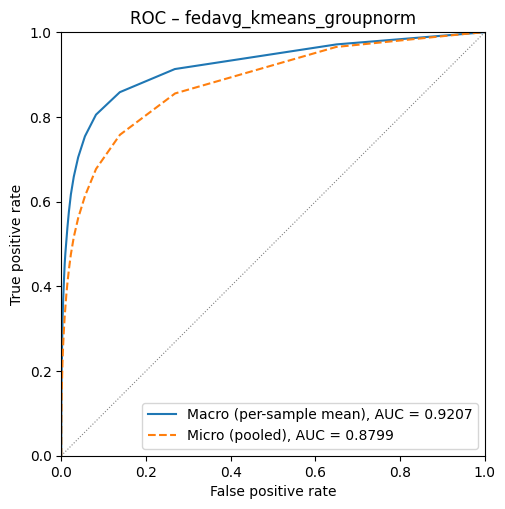

ROC AUC (macro): 0.9207
ROC AUC (micro): 0.8799


In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


csv_file = "work_dirs/fedavg_kmeans/roc_prc.csv"

df = pd.read_csv(csv_file, header=None, names=["threshold", "id", "tn", "fp", "fn", "tp"])


t = df

no_negatives      = (t["fp"] == 0) & (t["tn"] == 0)
no_positives      = (t["tp"] == 0) & (t["fn"] == 0)
no_pred_positives = (t["tp"] == 0) & (t["fp"] == 0)
df = t[~(no_negatives | no_positives | no_pred_positives)]

df_filtered = df[df["threshold"] == 0.1].copy()



display(df_filtered.head())

df_filtered['accuracy'] = (df_filtered['tp'] + df_filtered['tn']) / (df_filtered['tp'] + df_filtered['tn'] + df_filtered['fp'] + df_filtered['fn'])

display(df_filtered.head())
print(f"Accuracy at threshold 0.1: {df_filtered['accuracy'].mean():.4f}")
print(f"TOTAL: tp = {df['tp'].sum()}, fp = {df['fp'].sum()}, tn = {df['tn'].sum()}, fn = {df['fn'].sum()}, ACC = {(df['tp'].sum() + df['tn'].sum()) / (df['tp'].sum() + df['tn'].sum() + df['fp'].sum() + df['fn'].sum()):.4f}")

# ---------- ROC curve ----------
df["pos"] = df["tp"] + df["fn"]   # actual positives, constant across thresholds
df["neg"] = df["fp"] + df["tn"]   # actual negatives, constant across thresholds

# Macro: per-sample TPR/FPR, averaged over samples at each threshold
valid = df[(df["pos"] > 0) & (df["neg"] > 0)].copy()
valid["tpr"] = valid["tp"] / valid["pos"]
valid["fpr"] = valid["fp"] / valid["neg"]
macro = valid.groupby("threshold")[["fpr", "tpr"]].mean()

# Micro: pool the confusion counts over all samples at each threshold
counts = df.groupby("threshold")[["tp", "fp", "tn", "fn"]].sum()
micro = pd.DataFrame({
    "fpr": counts["fp"] / (counts["fp"] + counts["tn"]),
    "tpr": counts["tp"] / (counts["tp"] + counts["fn"]),
})

def roc_points_and_auc(roc):
    # High -> low threshold gives increasing FPR; pin the (0,0) and (1,1) endpoints
    r = roc.sort_index(ascending=False)
    fpr = np.r_[0.0, r["fpr"].to_numpy(), 1.0]
    tpr = np.r_[0.0, r["tpr"].to_numpy(), 1.0]
    auc = np.sum(np.diff(fpr) * (tpr[1:] + tpr[:-1]) / 2)  # trapezoidal rule
    return fpr, tpr, auc

fpr_ma, tpr_ma, auc_ma = roc_points_and_auc(macro)
fpr_mi, tpr_mi, auc_mi = roc_points_and_auc(micro)

fig, ax = plt.subplots(figsize=(5.5, 5.5))
ax.plot(fpr_ma, tpr_ma, label=f"Macro (per-sample mean), AUC = {auc_ma:.4f}")
ax.plot(fpr_mi, tpr_mi, linestyle="--", label=f"Micro (pooled), AUC = {auc_mi:.4f}")
ax.plot([0, 1], [0, 1], color="gray", linestyle=":", linewidth=0.8)
ax.set_xlabel("False positive rate")
ax.set_ylabel("True positive rate")
ax.set_title("ROC – fedavg_kmeans_groupnorm")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_aspect("equal")
ax.legend(loc="lower right")
plt.show()

print(f"ROC AUC (macro): {auc_ma:.4f}")
print(f"ROC AUC (micro): {auc_mi:.4f}")

